In [1]:
import os
import json
import duckdb
import pandas as pd
import numpy as np
import igraph as ig

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = "anchors"
np.random.seed(42)


In [3]:
BASE_DIR = "anchors"
os.makedirs(BASE_DIR, exist_ok=True)

min_blocks = 3
behavior_window_len = 30        # days before graph_end_date
prediction_window_len = 30      # days after anchor


In [23]:
anchor_dates = pd.date_range(
    start="2024-03-01",
    end="2024-11-01",
    freq="MS"   # Month Start
)

anchor_dates


DatetimeIndex(['2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01',
               '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01'],
              dtype='datetime64[ns]', freq='MS')

In [6]:
con = duckdb.connect()


In [21]:
def build_anchor(anchor_date):

    anchor_str = anchor_date.strftime("%Y-%m")
    anchor_dir = os.path.join(BASE_DIR, anchor_str)
    os.makedirs(anchor_dir, exist_ok=True)

    # --- Dates ---
    graph_end_date = anchor_date - pd.Timedelta(days=1)
    block_window_start = anchor_date
    block_window_end = anchor_date + pd.Timedelta(days=prediction_window_len - 1)
    behavior_start = graph_end_date - pd.Timedelta(days=behavior_window_len - 1)

    print(f"\n=== Building anchor {anchor_str} ===")
    con.execute(f"""
    CREATE OR REPLACE TEMP TABLE heavy_blockers AS
    SELECT did_id
    FROM read_parquet('blocks.parquet')
    WHERE created_date BETWEEN DATE '{block_window_start}' - INTERVAL 1 MONTH
                           AND DATE '{block_window_start}' - INTERVAL 1 DAY
    GROUP BY did_id
    HAVING COUNT(*) >= {min_blocks}
    """)

    num_blockers = con.execute(
        "SELECT COUNT(*) FROM heavy_blockers"
    ).fetchone()[0]

    if num_blockers < 500:
        print("Too few heavy blockers — skipping")
        return

    print(f"Heavy blockers: {num_blockers}")
    con.execute(f"""
    CREATE OR REPLACE TEMP TABLE follow_edges AS
    SELECT DISTINCT
        f.did_id AS src,
        f.subject_did_id AS dst
    FROM read_parquet('follows.parquet') f
    JOIN heavy_blockers b1 ON f.did_id = b1.did_id
    JOIN heavy_blockers b2 ON f.subject_did_id = b2.did_id
    WHERE f.created_date <= DATE '{graph_end_date}'
    """)
    con.execute(f"""
    CREATE OR REPLACE TEMP TABLE reply_edges AS
    SELECT DISTINCT
        p.did_id AS src,
        p.reply_parent_did_id AS dst
    FROM read_parquet('posts.parquet') p
    JOIN heavy_blockers b1 ON p.did_id = b1.did_id
    JOIN heavy_blockers b2 ON p.reply_parent_did_id = b2.did_id
    WHERE p.reply_parent_did_id IS NOT NULL
      AND p.created_date <= DATE '{graph_end_date}'
    """)
    con.execute("""
    CREATE OR REPLACE TEMP TABLE interaction_edges AS
    SELECT src, dst
    FROM (
        SELECT src, dst FROM follow_edges
        UNION
        SELECT src, dst FROM reply_edges
    )
    WHERE src IS NOT NULL
      AND dst IS NOT NULL
      AND src != dst
    """)
    edges = con.execute(
        "SELECT src, dst FROM interaction_edges"
    ).fetchdf()

    g = ig.Graph.TupleList(
        edges.itertuples(index=False),
        directed=True
    )

    g.simplify(multiple=True, loops=True)

    g.write_pickle(os.path.join(anchor_dir, "graph.pkl"))

    print(g.summary())
    g_und = g.as_undirected()

    graph_features = pd.DataFrame({
        "did_id": g.vs["name"],
        "out_degree": g.outdegree(),
        "in_degree": g.indegree(),
        "pagerank": g.pagerank(),
        "core": g.coreness(),
        "clustering": g_und.transitivity_local_undirected(mode="zero"),
    })

    graph_features.to_parquet(
        os.path.join(anchor_dir, "graph_features.parquet")
    )
    behavior_df = con.execute(f"""
    SELECT
        did_id,
        COUNT(*) AS post_count,
        COUNT(reply_parent_did_id) AS reply_count,
        COUNT(DISTINCT reply_parent_did_id) AS unique_replied_to
    FROM read_parquet('posts.parquet')
    WHERE created_date BETWEEN DATE '{behavior_start}'
                            AND DATE '{graph_end_date}'
    GROUP BY did_id
    """).fetchdf()

    behavior_df.to_parquet(
        os.path.join(anchor_dir, "behavior_features.parquet")
    )


    behavior_df.to_parquet(
        os.path.join(anchor_dir, "behavior_features.parquet")
    )
    label_df = con.execute(f"""
    SELECT did_id, COUNT(*) AS future_blocks
    FROM read_parquet('blocks.parquet')
    WHERE created_date BETWEEN DATE '{block_window_start}'
                          AND DATE '{block_window_end}'
    GROUP BY did_id
    """).fetchdf()

    label_df.to_parquet(
        os.path.join(anchor_dir, "labels.parquet")
    )
    metadata = {
        "anchor": anchor_str,
        "graph_end_date": str(graph_end_date.date()),
        "behavior_window_len": behavior_window_len,
        "prediction_window_len": prediction_window_len,
        "num_nodes": g.vcount(),
        "num_edges": g.ecount(),
        "num_heavy_blockers": num_blockers
    }

    with open(os.path.join(anchor_dir, "metadata.json"), "w") as f:
        json.dump(metadata, f, indent=2)


In [24]:
for anchor in anchor_dates:
    build_anchor(anchor)


=== Building anchor 2024-03 ===
Heavy blockers: 27757


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

IGRAPH DN-- 26735 2387084 -- 
+ attr: name (v)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

IGRAPH DN-- 117562 11051122 -- 
+ attr: name (v)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [9]:
anchor_dirs = sorted([
    d for d in os.listdir(BASE_DIR)
    if os.path.isdir(os.path.join(BASE_DIR, d))
])

anchor_dirs


['2024-03',
 '2024-04',
 '2024-05',
 '2024-06',
 '2024-07',
 '2024-08',
 '2024-09',
 '2024-10',
 '2024-11',
 '2024-12']

In [10]:
def load_anchor(anchor_dir):
    path = os.path.join(BASE_DIR, anchor_dir)

    graph_features = pd.read_parquet(
        os.path.join(path, "graph_features.parquet")
    )
    behavior_features = pd.read_parquet(
        os.path.join(path, "behavior_features.parquet")
    )
    labels = pd.read_parquet(
        os.path.join(path, "labels.parquet")
    )

    df = (
        graph_features
        .merge(behavior_features, on="did_id", how="left")
        .merge(labels, on="did_id", how="left")
    )

    df.fillna(0, inplace=True)
    return df


In [11]:
def block_class(x):
    if x <=5:
        return 0
    elif x <= 15:
        return 1
    else:
        return 2


In [12]:
def engineer_features(df, behavior_window_len=30):

    # Ratios
    df["reply_ratio"] = df["reply_count"] / (df["post_count"] + 1)

    # Rates
    df["posts_per_day"] = df["post_count"] / behavior_window_len
    df["replies_per_day"] = df["reply_count"] / behavior_window_len

    # Network balance
    df["in_out_ratio"] = df["in_degree"] / (df["out_degree"] + 1)

    # Log transforms (skewed magnitude features)
    log_features = [
        "out_degree", "in_degree",
        "post_count", "reply_count",
        "posts_per_day", "replies_per_day"
    ]

    for col in log_features:
        df[col] = np.log1p(df[col])

    return df


In [13]:
ALL_FEATURES = [
    # Graph structure
    "out_degree",
    "in_degree",
    "pagerank",
    "core",
    "clustering",
    "in_out_ratio",

    # Activity intensity
    "posts_per_day",
    "replies_per_day",

    # Interaction style
    "reply_ratio"
]



In [14]:
base_anchor = anchor_dirs[0]
base_df = load_anchor(base_anchor)
base_df = engineer_features(base_df)
base_df["y"] = base_df["future_blocks"].apply(block_class)

corr = base_df[ALL_FEATURES].corr()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

DROP_FEATURES = [
    col for col in upper.columns
    if any(upper[col] > 0.85)
]

FINAL_FEATURES = [
    f for f in ALL_FEATURES
    if f not in DROP_FEATURES
]

FINAL_FEATURES


['out_degree',
 'pagerank',
 'clustering',
 'in_out_ratio',
 'posts_per_day',
 'reply_ratio']

In [15]:
results = []

for anchor in anchor_dirs:

    print(f"\nEvaluating anchor: {anchor}")

    df = load_anchor(anchor)
    df = engineer_features(df)
    df["y"] = df["future_blocks"].apply(block_class)

    # Skip unstable anchors
    if df["y"].nunique() < 3 or len(df) < 500:
        print("Skipping anchor (insufficient data)")
        continue

    X = df[FINAL_FEATURES]
    y = df["y"]

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        stratify=y,
        test_size=0.2,
        random_state=42
    )

    rf = RandomForestClassifier(
        n_estimators=600,
        max_depth=12,
        min_samples_leaf=30,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)

    results.append({
        "anchor": anchor,
        "n_users": len(df),
        "f1_macro": f1_score(y_val, y_pred, average="macro"),
        "f1_weighted": f1_score(y_val, y_pred, average="weighted"),
        "class2_recall": classification_report(
            y_val, y_pred, output_dict=True
        )["2"]["recall"]
    })



Evaluating anchor: 2024-03

Evaluating anchor: 2024-04

Evaluating anchor: 2024-05

Evaluating anchor: 2024-06

Evaluating anchor: 2024-07

Evaluating anchor: 2024-08

Evaluating anchor: 2024-09

Evaluating anchor: 2024-10

Evaluating anchor: 2024-11

Evaluating anchor: 2024-12


FileNotFoundError: [Errno 2] No such file or directory: 'anchors\\2024-12\\graph_features.parquet'

In [16]:
results_df = pd.DataFrame(results)
results_df


,anchor,n_users,f1_macro,f1_weighted,class2_recall
0,2024-03,26735,0.440438,0.531085,0.386149
1,2024-04,23344,0.438072,0.546931,0.356546
2,2024-05,18893,0.447283,0.496789,0.372657
3,2024-06,20366,0.423470,0.466089,0.351262
4,2024-07,23110,0.432217,0.497958,0.396842
5,2024-08,22759,0.440706,0.481432,0.454271
6,2024-09,34786,0.421885,0.430482,0.431530
7,2024-10,133067,0.452825,0.627518,0.460771
8,2024-11,117562,0.496129,0.564747,0.553555


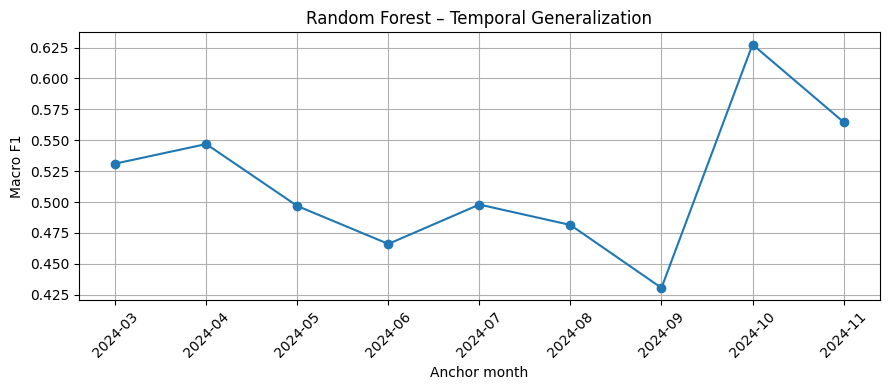

In [17]:
plt.figure(figsize=(9,4))
plt.plot(results_df["anchor"], results_df["f1_weighted"], marker="o")
plt.xticks(rotation=45)
plt.xlabel("Anchor month")
plt.ylabel("Macro F1")
plt.title("Random Forest – Temporal Generalization")
plt.grid(True)
plt.tight_layout()
plt.show()


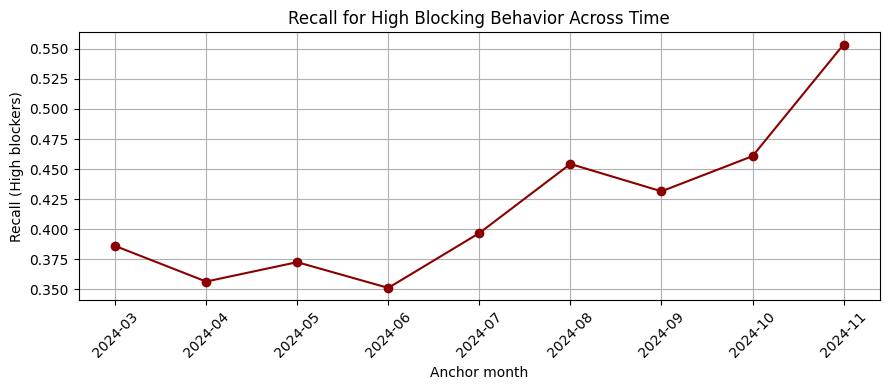

In [18]:
plt.figure(figsize=(9,4))
plt.plot(
    results_df["anchor"],
    results_df["class2_recall"],
    marker="o",
    color="darkred"
)
plt.xticks(rotation=45)
plt.xlabel("Anchor month")
plt.ylabel("Recall (High blockers)")
plt.title("Recall for High Blocking Behavior Across Time")
plt.grid(True)
plt.tight_layout()
plt.show()


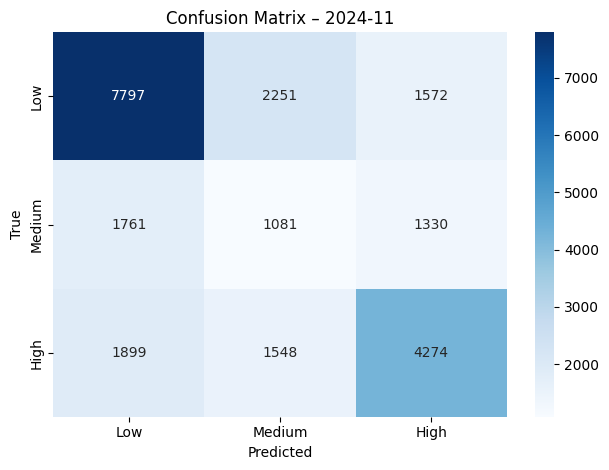

In [19]:
best_anchor = results_df.sort_values(
    "f1_macro", ascending=False
).iloc[0]["anchor"]

df = load_anchor(best_anchor)
df = engineer_features(df)
df["y"] = df["future_blocks"].apply(block_class)

X = df[FINAL_FEATURES]
y = df["y"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)

cm = confusion_matrix(y_val, y_pred)

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix – {best_anchor}")
plt.tight_layout()
plt.show()


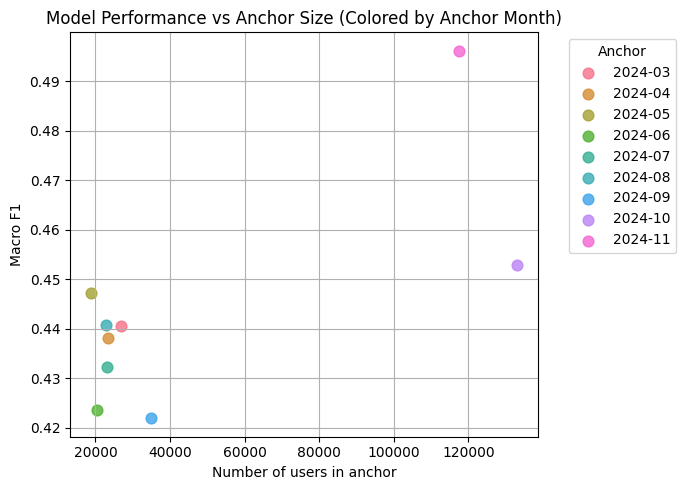

In [20]:
plt.figure(figsize=(7, 5))

anchors = results_df["anchor"].unique()
palette = sns.color_palette("husl", len(anchors))
color_map = dict(zip(anchors, palette))

for anchor in anchors:
    subset = results_df[results_df["anchor"] == anchor]
    plt.scatter(
        subset["n_users"],
        subset["f1_macro"],
        color=color_map[anchor],
        label=anchor,
        s=60,
        alpha=0.8
    )

plt.xlabel("Number of users in anchor")
plt.ylabel("Macro F1")
plt.title("Model Performance vs Anchor Size (Colored by Anchor Month)")
plt.grid(True)
plt.legend(
    title="Anchor",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()


In [25]:
# Build class distribution per anchor
dist_rows = []

for anchor in anchor_dirs:
    df = load_anchor(anchor)
    df["y"] = df["future_blocks"].apply(block_class)

    # skip unstable anchors
    if df["y"].nunique() < 3 or len(df) < 500:
        continue

    counts = df["y"].value_counts(normalize=True).sort_index()
    dist_rows.append({
        "anchor": anchor,
        "Low": counts.get(0, 0),
        "Medium": counts.get(1, 0),
        "High": counts.get(2, 0),
    })

dist_df = pd.DataFrame(dist_rows).sort_values("anchor")
dist_df


FileNotFoundError: [Errno 2] No such file or directory: 'anchors\\2024-12\\graph_features.parquet'

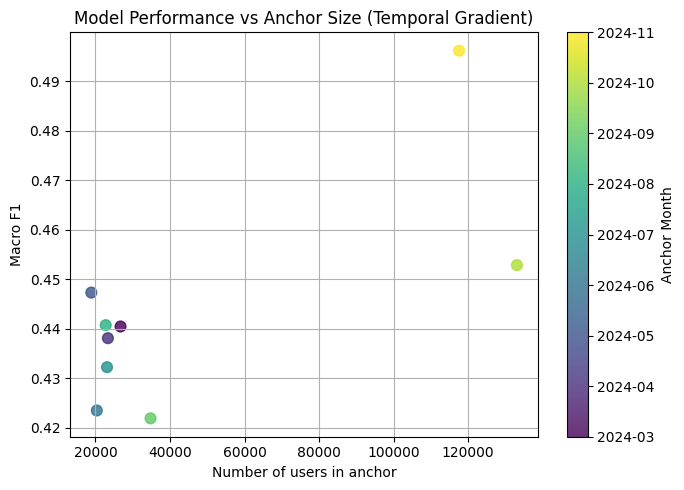

In [26]:
plt.figure(figsize=(7, 5))

anchors_sorted = sorted(results_df["anchor"].unique())
anchor_to_num = {a: i for i, a in enumerate(anchors_sorted)}

colors = results_df["anchor"].map(anchor_to_num)

sc = plt.scatter(
    results_df["n_users"],
    results_df["f1_macro"],
    c=colors,
    cmap="viridis",
    s=60,
    alpha=0.8
)

cbar = plt.colorbar(sc)
cbar.set_ticks(list(anchor_to_num.values()))
cbar.set_ticklabels(anchors_sorted)
cbar.set_label("Anchor Month")

plt.xlabel("Number of users in anchor")
plt.ylabel("Macro F1")
plt.title("Model Performance vs Anchor Size (Temporal Gradient)")
plt.grid(True)
plt.tight_layout()
plt.show()
